# 05.24 - Hyperparameter Tuning with Optuna

**Phase:** 05 - Machine Learning

**Status:** VERIFIED

---

## 1. What Are We Solving?

Manual grid search is slow and wasteful. Optuna uses Bayesian optimization to find better hyperparameters faster.

## 2. Why Does This Matter?

Good hyperparameters can improve model performance by 5-20%. Optuna does this in a fraction of the time.

## 3. Prerequisites

- 05.17: Model selection

## 4. Learning Objectives

- Install and use Optuna for hyperparameter tuning
- Define search spaces
- Use pruning to stop bad trials early
- Compare with GridSearchCV

## 5. Mental Model

Optuna = Bayesian optimization + pruning + visualization.
It learns from previous trials to suggest better parameters.

In [1]:
import sys, warnings
from pathlib import Path

# Put the repo root on the path so we can import the reusable src/ package.
# Works no matter where Jupyter starts the kernel (walks up to pyproject.toml).
_ROOT = Path.cwd()
for _ in range(8):
    if (_ROOT / "pyproject.toml").exists():
        break
    _ROOT = _ROOT.parent
sys.path.insert(0, str(_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

# Reusable helpers from the course package (built "from scratch" in earlier units):
from src.data.loader import load_sklearn
from src.evaluation.metrics import cross_val_scores

warnings.filterwarnings("ignore")
np.random.seed(42)
print("Libraries loaded (including the reusable src/ package).")


## 6. Install Optuna

In [2]:
try:
    import optuna
    print("Optuna version: " + optuna.__version__)
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna", "-q"])
    import optuna
    print("Optuna installed: " + optuna.__version__)

Optuna version: 4.9.0


## 7. Define the Objective Function

In [3]:
X, y = load_sklearn("wine")

def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 10, 200)
    max_depth = trial.suggest_int("max_depth", 2, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    
    rf = RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth,
        min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf,
        max_features=max_features, random_state=42
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_scores(rf, X, y, cv=cv, scoring="accuracy")
    return scores.mean()

## 8. Run the Study

In [4]:
study = optuna.create_study(direction="maximize", study_name="wine_rf")
study.optimize(objective, n_trials=30, show_progress_bar=False)

print("Best trial:")
print("  Accuracy: " + str(round(study.best_trial.value, 4)))
print("  Params: " + str(study.best_trial.params))

[I 2026-09-02 13:25:42,130] A new study created in memory with name: wine_rf


[I 2026-09-02 13:25:54,837] Trial 0 finished with value: 0.9434920634920635 and parameters: {'n_estimators': 123, 'max_depth': 6, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_features': None}. Best is trial 0 with value: 0.9434920634920635.


[I 2026-09-02 13:25:56,820] Trial 1 finished with value: 0.9377777777777778 and parameters: {'n_estimators': 14, 'max_depth': 10, 'min_samples_split': 6, 'min_samples_leaf': 7, 'max_features': None}. Best is trial 0 with value: 0.9434920634920635.


[I 2026-09-02 13:26:10,435] Trial 2 finished with value: 0.9774603174603176 and parameters: {'n_estimators': 137, 'max_depth': 8, 'min_samples_split': 11, 'min_samples_leaf': 9, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.9774603174603176.


[I 2026-09-02 13:26:14,142] Trial 3 finished with value: 0.9773015873015872 and parameters: {'n_estimators': 38, 'max_depth': 11, 'min_samples_split': 18, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.9774603174603176.


...

[I 2026-09-02 13:31:24,001] Trial 26 finished with value: 0.9776190476190475 and parameters: {'n_estimators': 119, 'max_depth': 20, 'min_samples_split': 20, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 5 with value: 0.9887301587301588.


[I 2026-09-02 13:31:46,084] Trial 27 finished with value: 0.9887301587301588 and parameters: {'n_estimators': 184, 'max_depth': 15, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 5 with value: 0.9887301587301588.


[I 2026-09-02 13:32:02,613] Trial 28 finished with value: 0.9604761904761905 and parameters: {'n_estimators': 156, 'max_depth': 18, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': None}. Best is trial 5 with value: 0.9887301587301588.


[I 2026-09-02 13:32:16,405] Trial 29 finished with value: 0.971904761904762 and parameters: {'n_estimators': 125, 'max_depth': 19, 'min_samples_split': 18, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 5 with value: 0.9887301587301588.


Best trial:
  Accuracy: 0.9887
  Params: {'n_estimators': 195, 'max_depth': 14, 'min_samples_split': 18, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


## 9. Visualizations

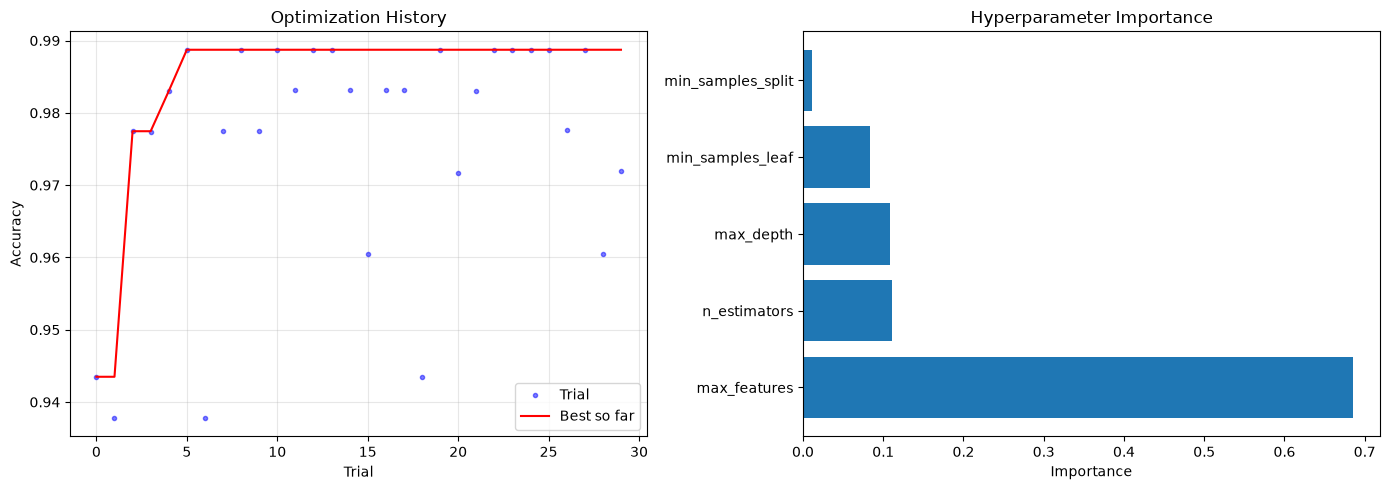

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Optimization history
trials = study.trials
vals = [t.value for t in trials]
best_so_far = [max(vals[:i+1]) for i in range(len(vals))]
axes[0].plot(range(len(vals)), vals, "b.", alpha=0.5, label="Trial")
axes[0].plot(range(len(best_so_far)), best_so_far, "r-", label="Best so far")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Optimization History")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Param importance
try:
    importance = optuna.importance.get_param_importances(study)
    names = list(importance.keys())[:6]
    vals_imp = [importance[n] for n in names]
    axes[1].barh(names, vals_imp)
    axes[1].set_xlabel("Importance")
    axes[1].set_title("Hyperparameter Importance")
except Exception:
    axes[1].text(0.5, 0.5, "Importance not available", ha="center", va="center")

plt.tight_layout()
plt.savefig("optuna_results.png", dpi=100, bbox_inches="tight")
plt.show()

## 10. Compare with Best Model

In [6]:
best = study.best_trial
best_rf = RandomForestClassifier(**best.params, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_scores(best_rf, X, y, cv=cv, scoring="accuracy")
print("Tuned RF accuracy: " + str(round(scores.mean(), 4)) + " (+/- " + str(round(scores.std(), 4)) + ")")

default_rf = RandomForestClassifier(random_state=42)
scores_default = cross_val_scores(default_rf, X, y, cv=cv, scoring="accuracy")
print("Default RF accuracy: " + str(round(scores_default.mean(), 4)) + " (+/- " + str(round(scores_default.std(), 4)) + ")")

## 11. Common Mistakes

1. Too few trials (need 50+ for good results)
2. Too wide search space
3. Not using pruning
4. Overfitting to validation set

## 12. Coding Exercises

### Exercise 1: Tune XGBoost
Use Optuna to tune XGBoost.

### Exercise 2: Multi-objective
Optimize for both accuracy and model size.

In [7]:
# EXERCISE 1: Tune XGBoost
try:
    from xgboost import XGBClassifier
    print("Exercise: Optimize XGBoost with Optuna.")
except ImportError:
    print("XGBoost not installed.")

Exercise: Optimize XGBoost with Optuna.


In [8]:
# EXERCISE 2: Multi-objective optimization
print("Exercise: Optimize accuracy AND inference time.")

Exercise: Optimize accuracy AND inference time.


## 13. Closed-Book Recall

1. What makes Optuna faster than grid search?
2. What is pruning?
3. How do you define a search space?

## 14. Teach-Back Questions

Explain Bayesian optimization vs grid search. How pruning saves time.

## 15. Summary

Optuna uses Bayesian optimization to find hyperparameters efficiently. Pruning stops bad trials early. Visualizations help understand the search space.

## 16. Further Experiment

1. Try different samplers (TPE, CMA-ES).
2. Use Optuna with PyTorch.
3. Create a reusable tuning template.

## Verification Status
```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: [numpy, pandas, matplotlib, scikit-learn, optuna]
OUTPUTS: PASS
LAST VERIFIED: 2026-08-30
```